# Sample for the Tuning of the DBSCAN Clustering Hyperparameters

In [ ]:
# Packages
import pandas as pd
import json
import gc
from pathlib import Path
import glob
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from sklearn.model_selection import train_test_split
from datetime import datetime


## Load Narrative_mentions.jsonl

In [1]:
pop_file = "../data/mentions/narrative_mentions.jsonl"

records = []

with open(pop_file, "r", encoding="utf-8") as f:
    for line in f:
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError:
            print(f"Skipping malformed line in {pop_file}")

mentions_df = pd.DataFrame(records)

print(mentions_df.shape)
print(mentions_df.columns)

# Only keep relevant columns for the sampling process
mentions_df = mentions_df[['paperId', 'text_type', 'id']] #free up storage

print(mentions_df.shape)
print(mentions_df.columns)

(537645, 15)
Index(['paperId', 'doi', 'oa_id', 'text_type', 'text_cleaned', 'match_type',
       'matched_seq', 'matched_char_start', 'matched_char_end', 'sentence_pos',
       'pos', 'id', 'context_token_ids', 'context_n_tokens',
       'matched_token_indices'],
      dtype='str')
(537645, 3)
Index(['paperId', 'text_type', 'id'], dtype='str')


## Inspect the Progress File for the bert-base Embeddings
Checkout if the filtering worked appropriately

In [3]:
# load process_log to remove filtered mentions (len >512 or not "narrative" or "narratives")
log_file = "../data/embeddings/bert-base/progress.json"

with open(log_file) as f:
    logs = json.load(f)

logs.keys()

dict_keys(['all_ids', 'ids_processed_n', 'ids_rm_len_n', 'ids_rm_len', 'ids_rm_match_n', 'ids_rm_match', 'to_process_n', 'to_process', 'start_time', 'end_time', 'elapsed_seconds'])

In [4]:
gc.collect()

432

If everything worked out as expected then len(mentions_df) should be equal to the information in the logfile like this: all_ids - (ids_rm_len_n + ids_rm_match_n)

In [5]:
print(logs["ids_rm_len_n"])
print(logs["ids_rm_match_n"])
print(logs["all_ids"] - (logs["ids_rm_len_n"] + logs["ids_rm_match_n"]))


312
38143
499190


In [6]:
# Load only the ids from the embeddings file
embeddings_path = Path("../data/embeddings/bert-base")
chunk_files = sorted((embeddings_path / "chunks").glob("chunk_*.parquet"))


bert_embeddings = pd.read_parquet(
        chunk_files,
        columns=["id"],
    )
bert_embeddings.shape

(499190, 1)

In [7]:
# All ids that are in the mentions_df, but we do not have bert_embeddings for
len(mentions_df[~mentions_df["id"].isin(list(bert_embeddings.id))]) 

38455

In [8]:
# The number are as expected:
print(len(logs["ids_rm_len"] + logs["ids_rm_match"]))

# Do they have overlaping ids, though? 
set(logs["ids_rm_len"] + logs["ids_rm_match"]) == set(mentions_df[~mentions_df["id"].isin(list(bert_embeddings.id))].id)

38455


True

In [9]:
# Remove everything from mentions_df that has no bert_embedding 
# (we know from the logfile why they do not have embeddings)
mentions_df = mentions_df.drop(mentions_df[~mentions_df["id"].isin(list(bert_embeddings.id))].index)

mentions_df.shape

#499190

(499190, 3)

## Load Paper Metadata (enriched with OpenAlex)

In [10]:
# ---------------------------------------------------
# 1. Find all batch files
# ---------------------------------------------------

files_meta = glob.glob("../data/enriched/filtered/enriched_batch_*.jsonl")

print(f"Found {len(files_meta)} files")

# ---------------------------------------------------
# 2. Load all records
# ---------------------------------------------------

records = []

for file in files_meta:
    with open(file, "r", encoding="utf-8") as f:
        for line in f:
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                print(f"Skipping malformed line in {file}")

# ---------------------------------------------------
# 3. Convert to DataFrame
# ---------------------------------------------------

oa_df = pd.DataFrame(records)

print(oa_df.shape)
print(oa_df.columns)

Found 4 files
(311686, 33)
Index(['paperId', 'title', 'venue', 'year', 'citationCount', 'fieldsOfStudy',
       'publicationTypes', 'authors', 'abstract', 'doi', 'pdf_url', 'oa_id',
       'oa_title', 'oa_publication_year', 'oa_language', 'oa_type',
       'oa_is_retracted', 'oa_cited_by_count',
       'oa_citation_normalized_percentile', 'oa_authors',
       'oa_source_display_name', 'oa_source_issn', 'oa_source_issn_l',
       'oa_source_type', 'oa_source_host_organization_name', 'oa_pdf_url',
       'oa_topics', 'oa_keywords', 'oa_concepts', 'oa_has_pdf',
       'oa_has_grobid_xml', 'oa_content_urls', 'abstract_source'],
      dtype='str')


In [11]:
# only keep the metadata of all papers that have at least one mention
print(len(oa_df["paperId"].unique()))


oa_df.drop(
    oa_df[~oa_df["paperId"].isin(list(mentions_df.paperId))].index,
    inplace=True
)

oa_df.shape

311686


(282768, 33)

In [12]:
# reduce the size of oa_df by removing excess columns
oa_df = oa_df[["paperId", "oa_topics", "fieldsOfStudy"]]

### Descriptive Statistic

In [13]:
# Distribution of the Semantic Scholar Fields-Of-Study 
oa_df["fieldsOfStudy"].value_counts()

fieldsOfStudy
[Sociology]                                  30953
[Medicine]                                   29488
[History]                                    18405
[Psychology]                                 15868
[Art]                                        12408
                                             ...  
[History, Art, Medicine]                         1
[Computer Science, Business, Engineering]        1
[Engineering, Materials Science]                 1
[Psychology, Art, Computer Science]              1
[Medicine, Mathematics, Computer Science]        1
Name: count, Length: 382, dtype: int64

In [14]:
# Distribution of the number of OpenAlex topics per paper
oa_df["oa_topics"].str.len().value_counts().sort_index()

oa_topics
0       423
1     44767
2     32022
3    205556
Name: count, dtype: int64

In [15]:
# Structure of OpenAlex topic entries
oa_df["oa_topics"][0]

[{'id': 'https://openalex.org/T11717',
  'display_name': 'Postcolonial and Cultural Literary Studies',
  'score': 0.9700000286102295,
  'subfield': 'Literature and Literary Theory',
  'field': 'Arts and Humanities',
  'domain': 'Social Sciences'}]

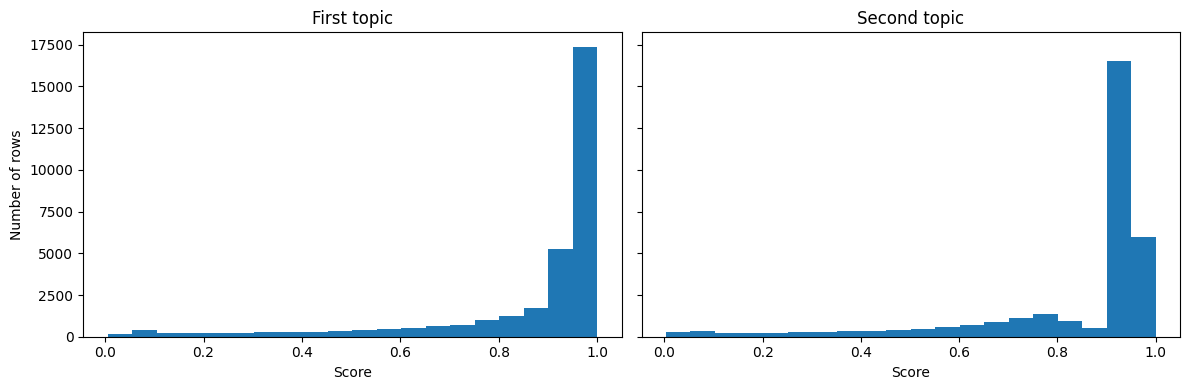

In [16]:
# Distribution of the confidence scores for the first and second topic
two_topics = oa_df[
    oa_df["oa_topics"].apply(lambda x: isinstance(x, list) and len(x) == 2)
]

first_scores = two_topics["oa_topics"].apply(lambda x: x[0]["score"])
second_scores = two_topics["oa_topics"].apply(lambda x: x[1]["score"])
third_scores = two_topics["oa_topics"].apply(lambda x: x[2]["score"])


fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].hist(first_scores, bins=20)
axes[0].set_title("First topic")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Number of rows")

axes[1].hist(second_scores, bins=20)
axes[1].set_title("Second topic")
axes[1].set_xlabel("Score")

plt.tight_layout()
plt.show()

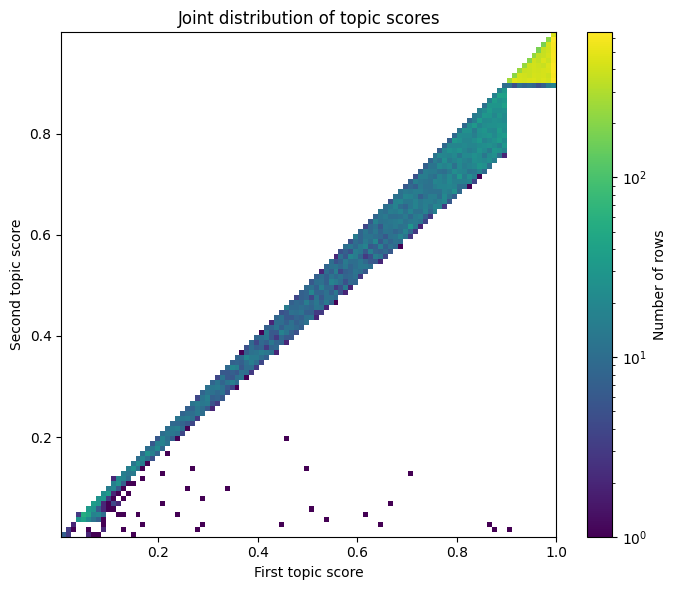

In [17]:
# JOINT DISTRIBUTION of the confidence scores for the first and second topic
# COLOR SCALE IS LOG TRANSFORMED

plt.figure(figsize=(7, 6))

plt.hist2d(
    first_scores,
    second_scores,
    bins=100,
    cmap="viridis",
    norm=LogNorm()
)

plt.colorbar(label="Number of rows")
plt.xlabel("First topic score")
plt.ylabel("Second topic score")
plt.title("Joint distribution of topic scores")

plt.tight_layout()
plt.show()

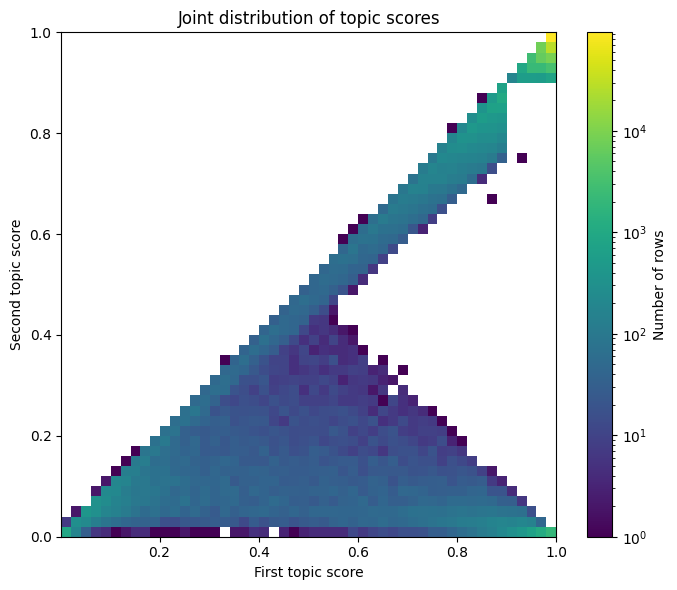

In [19]:
# Joint distribution of the confidence scores for the first and second topic
# COLOR SCALE IS LOG TRANSFORMED
# LESS BINS
plt.figure(figsize=(7, 6))

plt.hist2d(
    first_scores,
    second_scores,
    bins=50,
    cmap="viridis",
    norm=LogNorm()
)

plt.colorbar(label="Number of rows")
plt.xlabel("First topic score")
plt.ylabel("Second topic score")
plt.title("Joint distribution of topic scores")

plt.tight_layout()
plt.show()

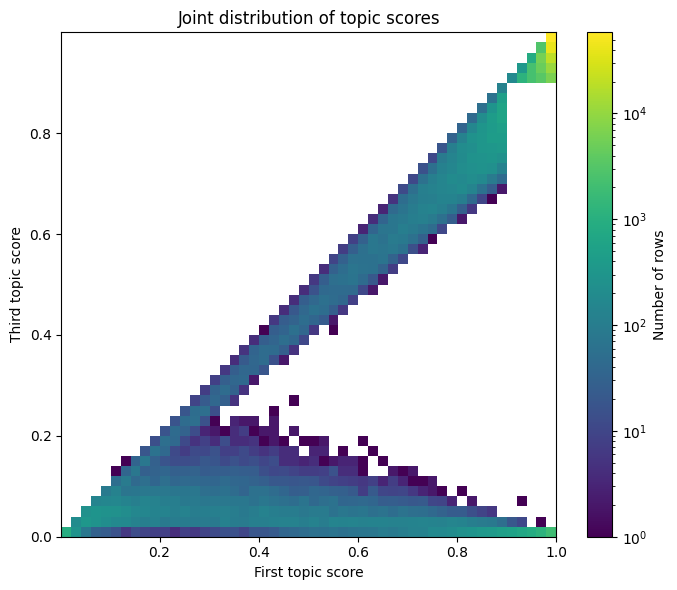

In [20]:
# Joint distribution of the confidence scores for the first and second topic
# Color scale is log transformed
# Less bins
# FIRST VS THIRD TOPIC'S SCORE

plt.figure(figsize=(7, 6))

plt.hist2d(
    first_scores,
    third_scores,
    bins=50,
    cmap="viridis",
    norm=LogNorm()
)

plt.colorbar(label="Number of rows")
plt.xlabel("First topic score")
plt.ylabel("Third topic score")
plt.title("Joint distribution of topic scores")

plt.tight_layout()
plt.show()

### Field overlap of the OpenAlex topics
Topics is the most fine-grained research field classification of OpenAlex.  
Each topic belongs to exact one field. OpenAlex field is from its coarsity comparable to Fields-Of-Study from SemanticScholar

In [21]:
# Note the structure of oa_topics if there is more than one topic assigned to a paper
oa_df["oa_topics"][2]

[{'id': 'https://openalex.org/T10103',
  'display_name': 'Reading and Literacy Development',
  'score': 0.6111999750137329,
  'subfield': 'Developmental and Educational Psychology',
  'field': 'Psychology',
  'domain': 'Social Sciences'},
 {'id': 'https://openalex.org/T10730',
  'display_name': 'Language Development and Disorders',
  'score': 0.23090000450611115,
  'subfield': 'Developmental and Educational Psychology',
  'field': 'Psychology',
  'domain': 'Social Sciences'},
 {'id': 'https://openalex.org/T10465',
  'display_name': 'Neurobiology of Language and Bilingualism',
  'score': 0.08229999989271164,
  'subfield': 'Cognitive Neuroscience',
  'field': 'Neuroscience',
  'domain': 'Life Sciences'}]

In [22]:
# Get for each topic its field and for each paper only keep the unique fields
oa_df["unique_fields"] = oa_df["oa_topics"].apply(
    lambda x: set([i["field"] for i in x]) if isinstance(x, list) and len(x) > 0 else None
)

In [23]:
# Distribution of number of fields per paper (oa_topics)
oa_df["unique_fields"].str.len().value_counts().sort_index()

unique_fields
1.0    124592
2.0    120702
3.0     37051
Name: count, dtype: int64

In [24]:
oa_df.head()

,paperId,oa_topics,fieldsOfStudy,unique_fields
0,0000278bfcd5dfc1d586156ccff16e168f238e83,"[{'id': 'https://openalex.org/T11717', 'displa...",[History],{Arts and Humanities}
1,4aae5a329915daacf79c4354ec5c72d136424348,"[{'id': 'https://openalex.org/T13256', 'displa...",[Art],{Social Sciences}
2,4aaeb618b4e06b682c54f3db0eace3690b07c01a,"[{'id': 'https://openalex.org/T10103', 'displa...",[Medicine],"{Psychology, Neuroscience}"
3,4aaf4dfb89a21da3056618c21f92feb93abc3b40,"[{'id': 'https://openalex.org/T12678', 'displa...",[Sociology],"{Arts and Humanities, Social Sciences}"
4,4aaf8289a6d32eefa9cb14263e63bf92379b5432,"[{'id': 'https://openalex.org/T11120', 'displa...",[Sociology],"{Social Sciences, Economics, Econometrics and ..."


In [14]:
def get_dominant_field(topics):
    """
    Identify the dominant and second-ranked fields from a list of OpenAlex topics.

    Each topic is expected to be a dictionary containing a ``field`` and
    ``score``. Topics are grouped by field, and fields are ranked by the
    sum of the scores of all topics belonging to that field. The function
    returns the highest-scoring field, its total and average score, and,
    when available, the second-highest-scoring field and its average score.

    Parameters
    ----------
    topics : list of dict
        A list of OpenAlex topic dictionaries. Each dictionary should
        contain a ``field`` key and may contain a ``score`` key. Topics
        without a field are ignored, and missing scores default to 0.

    Returns
    -------
    pandas.Series
        A Series containing:

        - ``dominant_field`` : str or None
            The field with the highest accumulated topic score.
        - ``dominant_field_score`` : float or None
            The sum of scores for all topics belonging to the dominant field.
        - ``dominant_field_avg_score`` : float or None
            The mean topic score for the dominant field.
        - ``second_field`` : str or None
            The field with the second-highest accumulated topic score,
            if more than one field is present.
        - ``second_field_avg_score`` : float or None
            The mean topic score for the second-ranked field.

    Notes
    -----
    If ``topics`` is not a non-empty list, or if none of the topics
    contains a valid ``field``, all returned values are ``None``.
    """
    if not isinstance(topics, list) or len(topics) == 0:
        return pd.Series({
            "dominant_field": None,
            "dominant_field_score": None,
            "dominant_field_avg_score": None,
            "second_field": None,
            "second_field_avg_score": None
        })

    field_scores = {}

    for topic in topics:
        field = topic.get("field")
        score = topic.get("score", 0)

        if field is not None:
            field_scores.setdefault(field, []).append(score)

    if not field_scores:
        return pd.Series({
            "dominant_field": None,
            "dominant_field_score": None,
            "dominant_field_avg_score": None,
            "second_field": None,
            "second_field_avg_score": None
        })

    # Sort fields by their accumulated score
    sorted_fields = sorted(
        field_scores,
        key=lambda field: sum(field_scores[field]),
        reverse=True
    )

    # Dominant field
    dominant_field = sorted_fields[0]
    dominant_scores = field_scores[dominant_field]

    # Second field, if one exists
    if len(sorted_fields) > 1:
        second_field = sorted_fields[1]
        second_scores = field_scores[second_field]
        second_avg_score = sum(second_scores) / len(second_scores)
    else:
        second_field = None
        second_avg_score = None

    return pd.Series({
        "dominant_field": dominant_field,
        "dominant_field_score": sum(dominant_scores),
        "dominant_field_avg_score": sum(dominant_scores) / len(dominant_scores),
        "second_field": second_field,
        "second_field_avg_score": second_avg_score
    })


oa_df[
    [
        "dominant_field",
        "dominant_field_score",
        "dominant_field_avg_score",
        "second_field",
        "second_field_avg_score"
    ]
] = oa_df["oa_topics"].apply(get_dominant_field)

In [15]:
oa_df.head()

,paperId,oa_topics,fieldsOfStudy,dominant_field,dominant_field_score,dominant_field_avg_score,second_field,second_field_avg_score
0,0000278bfcd5dfc1d586156ccff16e168f238e83,"[{'id': 'https://openalex.org/T11717', 'displa...",[History],Arts and Humanities,0.9700,0.97000,NaN,NaN
1,4aae5a329915daacf79c4354ec5c72d136424348,"[{'id': 'https://openalex.org/T13256', 'displa...",[Art],Social Sciences,1.8446,0.92230,NaN,NaN
2,4aaeb618b4e06b682c54f3db0eace3690b07c01a,"[{'id': 'https://openalex.org/T10103', 'displa...",[Medicine],Psychology,0.8421,0.42105,Neuroscience,0.0823
3,4aaf4dfb89a21da3056618c21f92feb93abc3b40,"[{'id': 'https://openalex.org/T12678', 'displa...",[Sociology],Arts and Humanities,0.9109,0.91090,Social Sciences,0.9015
4,4aaf8289a6d32eefa9cb14263e63bf92379b5432,"[{'id': 'https://openalex.org/T11120', 'displa...",[Sociology],Social Sciences,1.9863,0.99315,"Economics, Econometrics and Finance",0.9938


In [16]:
# How many ambigious cases do we have when using summing of the scores?
len(oa_df[oa_df["dominant_field_avg_score"] < oa_df["second_field_avg_score"]])

45210

In [17]:
# Let's take a look at some of those cases
oa_df[oa_df["dominant_field_avg_score"] < oa_df["second_field_avg_score"]].head()

,paperId,oa_topics,fieldsOfStudy,dominant_field,dominant_field_score,dominant_field_avg_score,second_field,second_field_avg_score
4,4aaf8289a6d32eefa9cb14263e63bf92379b5432,"[{'id': 'https://openalex.org/T11120', 'displa...",[Sociology],Social Sciences,1.9863,0.99315,"Economics, Econometrics and Finance",0.9938
8,4ab01a952e961ed26efbd6f60898fbd20ec722f2,"[{'id': 'https://openalex.org/T13729', 'displa...",[History],Social Sciences,0.2111,0.10555,Environmental Science,0.1160
23,4ab29bb07a223ca3035c369025b9759aa93c4859,"[{'id': 'https://openalex.org/T11104', 'displa...",[History],Arts and Humanities,1.9843,0.99215,Psychology,0.9983
40,4ab6bb80bd413c39d4ebb208221d72390c06d7c7,"[{'id': 'https://openalex.org/T13766', 'displa...",None,Arts and Humanities,1.9887,0.99435,Social Sciences,0.9951
44,4ab76b43d145878f2518dc55303b1d91848a8050,"[{'id': 'https://openalex.org/T10569', 'displa...",[Medicine],Medicine,1.9977,0.99885,Health Professions,0.9994


<Axes: >

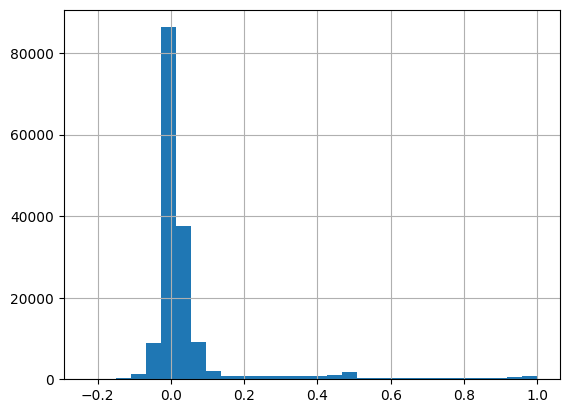

In [29]:
# dominant average score - second to dominant average score 
# Negative values are an expected artefact of the approach (sum and not average)
delta = oa_df["dominant_field_avg_score"]-oa_df["second_field_avg_score"]

delta.hist(bins=30)

## Merge oa_df Topics with Mentions_df

In [18]:
mentions_df = mentions_df.merge(
    oa_df[["paperId", "dominant_field"]],
    on="paperId",
    how="left"
)

In [31]:
mentions_df.head()

,paperId,text_type,id,dominant_field
0,0000278bfcd5dfc1d586156ccff16e168f238e83,title,0,Arts and Humanities
1,0000278bfcd5dfc1d586156ccff16e168f238e83,abstract,1,Arts and Humanities
2,4aae5a329915daacf79c4354ec5c72d136424348,abstract,2,Social Sciences
3,4aaeb618b4e06b682c54f3db0eace3690b07c01a,title,3,Psychology
4,4aaeb618b4e06b682c54f3db0eace3690b07c01a,abstract,4,Psychology


In [19]:
# How many observations would be in each strata?
population = pd.crosstab(
    mentions_df["dominant_field"],
    mentions_df["text_type"],
    dropna=False
) # how are the strata handled with less than one to sample?

population

text_type,abstract,title
dominant_field,,
Agricultural and Biological Sciences,3296,437
Arts and Humanities,93561,15231
"Biochemistry, Genetics and Molecular Biology",1990,248
"Business, Management and Accounting",9612,1482
Chemical Engineering,10,0
Chemistry,149,14
Computer Science,20396,4401
Decision Sciences,1841,267
Dentistry,257,22


In [20]:
del oa_df
del bert_embeddings

gc.collect()

0

# The sampling

In [21]:
# sort mentions_df
mentions_df = mentions_df.sort_values(by=["id"])

In [22]:
# combine research field and source of the mention (text_type) in one column
# for the stratification 
# Kepp missing as its own category
stratify_col = (
    mentions_df["dominant_field"].fillna("MISSING").astype(str)
    + "_"
    + mentions_df["text_type"].fillna("MISSING").astype(str)
)

# 10% sample; with seed; 
# stratified on a combination of oa_topics dominant field and text type
_, stratified_sample = train_test_split(
    mentions_df,
    test_size=0.1,
    stratify=stratify_col,
    random_state=7
)

stratified_sample.shape

(49919, 4)

In [23]:
# Strata distribution in the sample
sample = pd.crosstab(
    stratified_sample["dominant_field"],
    stratified_sample["text_type"],
    dropna=False
)
sample

text_type,abstract,title
dominant_field,,
Agricultural and Biological Sciences,330,44
Arts and Humanities,9356,1523
"Biochemistry, Genetics and Molecular Biology",199,25
"Business, Management and Accounting",961,148
Chemical Engineering,1,0
Chemistry,15,1
Computer Science,2040,440
Decision Sciences,184,27
Dentistry,26,2


In [24]:
# Actual sampled fraction per strata
sampling_fraction = sample.div(population).fillna(0)
sampling_fraction

text_type,abstract,title
dominant_field,,
Agricultural and Biological Sciences,0.100121,0.100686
Arts and Humanities,0.099999,0.099993
"Biochemistry, Genetics and Molecular Biology",0.100000,0.100806
"Business, Management and Accounting",0.099979,0.099865
Chemical Engineering,0.100000,0.000000
Chemistry,0.100671,0.071429
Computer Science,0.100020,0.099977
Decision Sciences,0.099946,0.101124
Dentistry,0.101167,0.090909


In [25]:
population_long = (
    mentions_df
    .groupby(["dominant_field", "text_type"], dropna=False)
    .size()
    .rename("population")
)

sample_long = (
    stratified_sample
    .groupby(["dominant_field", "text_type"], dropna=False)
    .size()
    .rename("sample")
)

sampling = pd.concat([population_long, sample_long], axis=1).fillna(0)

sampling["fraction"] = sampling["sample"] / sampling["population"]
sampling["percentage"] = sampling["fraction"] * 100

sampling.reset_index()

plot_data = (
    sampling
    .reset_index()
    .query("text_type in ['abstract', 'title']")
    .pivot(
        index="dominant_field",
        columns="text_type",
        values="percentage"
    )
    .fillna(0)
)

plot_data

text_type,abstract,title
dominant_field,,
NaN,10.095238,9.890110
Agricultural and Biological Sciences,10.012136,10.068650
Arts and Humanities,9.999893,9.999343
"Biochemistry, Genetics and Molecular Biology",10.000000,10.080645
"Business, Management and Accounting",9.997919,9.986505
Chemical Engineering,10.000000,0.000000
Chemistry,10.067114,7.142857
Computer Science,10.001961,9.997728
Decision Sciences,9.994568,10.112360


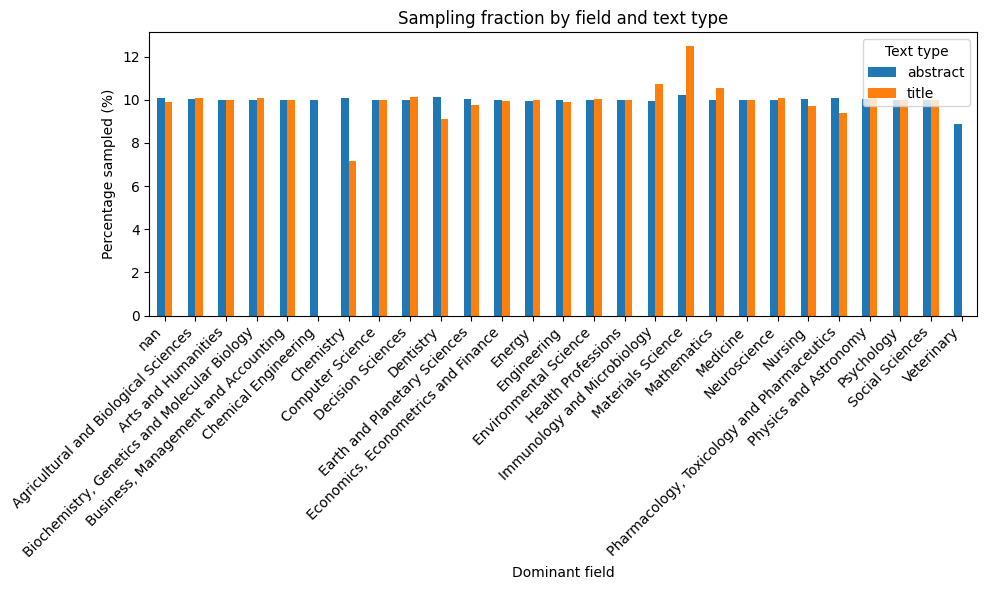

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Dominant field")
plt.ylabel("Percentage sampled (%)")
plt.title("Sampling fraction by field and text type")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Text type")
plt.tight_layout()
plt.show()

## Store the Sampling Results

In [27]:
# Create directory for the sample
output_dir = Path("../data/sample")
output_dir.mkdir(parents=True, exist_ok=True)

# Keep only the ids of the sample (for light storage)
sampled_ids = stratified_sample[["paperId", "id"]]

# Prep Data to keep of the sampling process
sample_info = {
    # keep the name of the notebook that generated the sample
    "sample_source": "sample.ipynb",

    # keep the path of all data used during the sample process
    "input_data": {
        "population": {
            "path": str(Path(pop_file).resolve()),
        },
        "filter": {
            "path": str(Path(embeddings_path).resolve()),
        },
        "additional_meta": {
            "path": str(Path("../data/enriched/filtered").resolve()),
        }
    },

    # keep set up of the sampling function
    "sampling": {
        "strata": ["dominant_field", "text_type"],
        "percentage": 0.10,
        "random_seed": 7
    },

    # keep the distribution over the strata in sample and population
    "sampling_by_stratum": (
        sampling
        .reset_index()
        .to_dict(orient="records")
    ),

    # keep the ids that belong to the sample
    "sample": sampled_ids.to_dict(orient="records")
}


with open(output_dir / "sample_tuning_10per.json", "w") as f:
    json.dump(sample_info, f, indent=3)